# Vendor Performance Analysis

Understanding the dataset to explore how the data is present in the database and if there is a need of creating some aggregated tables that can help with:

Vendor selection for profitability
Product Pricing Optimization

In [ ]:
import sqlite3
import pandas as pd

# creating database connection
conn = sqlite3.connect('inventory.db')

In [4]:
engine = create_engine('sqlite:///inventory.db')


In [6]:
for file in os.listdir('Data_vendorperformance'):
    if '.csv' in file:
        df = pd.read_csv('Data_vendorperformance/'+file)
        print (df.shape)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'Data_vendorperformance'

In [12]:
import os
print(os.getcwd())

C:\Users\Bodhiswatta Mukherje


In [15]:
import os
print(os.listdir())


['.anaconda', '.conda', '.condarc', '.continuum', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.ms-ad', '3D Objects', 'anaconda', 'anaconda3', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Data_vendorperformance', 'Documents', 'Downloads', 'Favorites', 'Links', 'Local Settings', 'Microsoft', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{aecaa157-34a9-11f0-a71a-e53ed5bd6c53}.TxR.0.regtrans-ms', 'NTUSER.DAT{aecaa157-34a9-11f0-a71a-e53ed5bd6c53}.TxR.1.regtrans-ms', 'NTUSER.DAT{aecaa157-34a9-11f0-a71a-e53ed5bd6c53}.TxR.2.regtrans-ms', 'NTUSER.DAT{aecaa157-34a9-11f0-a71a-e53ed5bd6c53}.TxR.blf', 'NTUSER.DAT{aecaa158-34a9-11f0-a71a-e53ed5bd6c53}.TM.blf', 'NTUSER.DAT{aecaa158-34a9-11f0-a71a-e53ed5bd6c53}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{aecaa158-34a9-11f0-a71a-e53ed5bd6c53}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'Recent', 'Saved Games', 'ScStore

In [16]:
import os
print(os.path.isdir('Data_vendorperformance'))

True


In [17]:
import os
print(os.listdir('Data_vendorperformance'))

['data']


In [19]:
import os
import pandas as pd

folder = 'Data_vendorperformance/data'

for file in os.listdir(folder):
    if file.endswith('.csv'):
        path = os.path.join(folder, file)
        df = pd.read_csv(path)
        print(file, df.shape)

begin_inventory.csv (206529, 9)
end_inventory.csv (224489, 9)
purchases.csv (2372474, 16)
purchase_prices.csv (12261, 9)
sales.csv (12825363, 14)
vendor_invoice.csv (5543, 10)


In [20]:
import sqlite3

In [21]:
conn = sqlite3.connect('inventory.db')

In [24]:
import os
import pandas as pd
import sqlite3

folder = 'Data_vendorperformance/data'
conn = sqlite3.connect("inventory.db")

for file in os.listdir(folder):
    if file.endswith('.csv'):
        path = os.path.join(folder, file)
        
        df = pd.read_csv(path)
        
        # table name = file name without .csv
        table_name = file.replace('.csv', '')
        
        df.to_sql(table_name, conn, if_exists='replace', index=False)
        print(f"Loaded {file} → table: {table_name}")

conn.close()

Loaded begin_inventory.csv → table: begin_inventory
Loaded end_inventory.csv → table: end_inventory
Loaded purchases.csv → table: purchases
Loaded purchase_prices.csv → table: purchase_prices
Loaded sales.csv → table: sales
Loaded vendor_invoice.csv → table: vendor_invoice


In [25]:
conn = sqlite3.connect("inventory.db")

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

conn.close()

              name
0  begin_inventory
1    end_inventory
2        purchases
3  purchase_prices
4            sales
5   vendor_invoice


In [31]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("inventory.db")

df = pd.read_sql("Select count(*) FROM purchases", conn)
print(df)

conn.close()

   count(*)
0   2372474


In [42]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("inventory.db")  # 🔥 reopen connection

result = []

for table in tables['name']:
    count = pd.read_sql(f"SELECT COUNT(*) as count FROM {table}", conn)
    result.append((table, count['count'][0]))

df_counts = pd.DataFrame(result, columns=['Table Name', 'Row Count'])
print(df_counts)

conn.close()

        Table Name  Row Count
0  begin_inventory     206529
1    end_inventory     224489
2        purchases    2372474
3  purchase_prices      12261
4            sales   12825363
5   vendor_invoice       5543


In [49]:
import sqlite3
import pandas as pd

with sqlite3.connect("inventory.db") as conn:
    tables = pd.read_sql("""
        SELECT name FROM sqlite_master WHERE type='table'
    """, conn)['name']

    for table in tables:
        print(f"\nTable: {table}")
        df = pd.read_sql(f"SELECT * FROM {table} LIMIT 5", conn)
        print(df)


Table: begin_inventory
         InventoryId  Store          City  Brand                  Description  \
0  1_HARDERSFIELD_58      1  HARDERSFIELD     58  Gekkeikan Black & Gold Sake   
1  1_HARDERSFIELD_60      1  HARDERSFIELD     60       Canadian Club 1858 VAP   
2  1_HARDERSFIELD_62      1  HARDERSFIELD     62     Herradura Silver Tequila   
3  1_HARDERSFIELD_63      1  HARDERSFIELD     63   Herradura Reposado Tequila   
4  1_HARDERSFIELD_72      1  HARDERSFIELD     72         No. 3 London Dry Gin   

    Size  onHand  Price   startDate  
0  750mL       8  12.99  2024-01-01  
1  750mL       7  10.99  2024-01-01  
2  750mL       6  36.99  2024-01-01  
3  750mL       3  38.99  2024-01-01  
4  750mL       6  34.99  2024-01-01  

Table: end_inventory
         InventoryId  Store          City  Brand                  Description  \
0  1_HARDERSFIELD_58      1  HARDERSFIELD     58  Gekkeikan Black & Gold Sake   
1  1_HARDERSFIELD_62      1  HARDERSFIELD     62     Herradura Silver Tequila

In [50]:
purchases = pd.read_sql_query("select * from purchases where VendorNumber = 4466",conn)
purchases

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
1,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
2,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
3,38_GOULCREST_5215,38,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8207,2023-12-27,2024-01-07,2024-01-19,2024-02-26,9.41,6,56.46,1
4,59_CLAETHORPES_5215,59,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8207,2023-12-27,2024-01-05,2024-01-19,2024-02-26,9.41,6,56.46,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2187,81_PEMBROKE_5215,81,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,13595,2024-12-20,2024-12-29,2025-01-04,2025-02-10,9.41,6,56.46,1
2188,62_KILMARNOCK_5255,62,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,13595,2024-12-20,2024-12-28,2025-01-04,2025-02-10,9.35,5,46.75,1
2189,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,13595,2024-12-20,2024-12-28,2025-01-04,2025-02-10,9.41,5,47.05,1
2190,6_GOULCREST_5215,6,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,13595,2024-12-20,2024-12-31,2025-01-04,2025-02-10,9.41,6,56.46,1


In [51]:
# choosing one vendor and filtering the different tables
purchase_prices = pd.read_sql_query("select * from purchase_prices where VendorNumber = 4466",conn)
purchase_prices

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,5215,TGI Fridays Long Island Iced,12.99,1750mL,1750,1,9.41,4466,AMERICAN VINTAGE BEVERAGE
1,5255,TGI Fridays Ultimte Mudslide,12.99,1750mL,1750,1,9.35,4466,AMERICAN VINTAGE BEVERAGE
2,3140,TGI Fridays Orange Dream,14.99,1750mL,1750,1,11.19,4466,AMERICAN VINTAGE BEVERAGE


In [53]:
purchases.groupby(['Brand','PurchasePrice'])[['Quantity','Dollars']].sum()

,,Quantity,Dollars
Brand,PurchasePrice,,
3140,11.19,4640,51921.60
5215,9.41,4923,46325.43
5255,9.35,6215,58110.25


In [59]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("inventory.db")

vendor_invoice = pd.read_sql("SELECT * FROM vendor_invoice", conn)

print(vendor_invoice.head())

   VendorNumber                   VendorName InvoiceDate  PONumber  \
0           105  ALTAMAR BRANDS LLC           2024-01-04      8124   
1          4466  AMERICAN VINTAGE BEVERAGE    2024-01-07      8137   
2           388  ATLANTIC IMPORTING COMPANY   2024-01-09      8169   
3           480  BACARDI USA INC              2024-01-12      8106   
4           516  BANFI PRODUCTS CORP          2024-01-07      8170   

       PODate     PayDate  Quantity    Dollars  Freight Approval  
0  2023-12-21  2024-02-16         6     214.26     3.47     None  
1  2023-12-22  2024-02-21        15     140.55     8.57     None  
2  2023-12-24  2024-02-16         5     106.60     4.61     None  
3  2023-12-20  2024-02-05     10100  137483.78  2935.20     None  
4  2023-12-24  2024-02-12      1935   15527.25   429.20     None  


In [60]:
vendor_invoice['PONumber'].nunique()


5543

In [61]:
vendor_invoice.columns

Index(['VendorNumber', 'VendorName', 'InvoiceDate', 'PONumber', 'PODate',
       'PayDate', 'Quantity', 'Dollars', 'Freight', 'Approval'],
      dtype='object')

In [18]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("inventory.db")

sales = pd.read_sql("SELECT * FROM sales", conn)

print(sales.head())

           InventoryId  Store  Brand                 Description        Size  \
0  1_HARDERSFIELD_1004      1   1004  Jim Beam w/2 Rocks Glasses       750mL   
1  1_HARDERSFIELD_1004      1   1004  Jim Beam w/2 Rocks Glasses       750mL   
2  1_HARDERSFIELD_1004      1   1004  Jim Beam w/2 Rocks Glasses       750mL   
3  1_HARDERSFIELD_1004      1   1004  Jim Beam w/2 Rocks Glasses       750mL   
4  1_HARDERSFIELD_1005      1   1005     Maker's Mark Combo Pack  375mL 2 Pk   

   SalesQuantity  SalesDollars  SalesPrice   SalesDate  Volume  \
0              1         16.49       16.49  2024-01-01   750.0   
1              2         32.98       16.49  2024-01-02   750.0   
2              1         16.49       16.49  2024-01-03   750.0   
3              1         14.49       14.49  2024-01-08   750.0   
4              2         69.98       34.99  2024-01-09   375.0   

   Classification  ExciseTax  VendorNo                   VendorName  
0               1       0.79     12546  JIM BEAM BRA

In [7]:
sales

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-01,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2,32.98,16.49,2024-01-02,750.0,1,1.57,12546,JIM BEAM BRANDS COMPANY
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-03,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
3,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,14.49,14.49,2024-01-08,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
4,1_HARDERSFIELD_1005,1,1005,Maker's Mark Combo Pack,375mL 2 Pk,2,69.98,34.99,2024-01-09,375.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12825358,9_BLACKPOOL_984,9,984,Patron XO Cafe Liqueur,750mL,1,25.99,25.99,2024-12-17,750.0,1,0.79,9165,ULTRA BEVERAGE COMPANY LLP
12825359,9_BLACKPOOL_984,9,984,Patron XO Cafe Liqueur,750mL,1,25.99,25.99,2024-12-21,750.0,1,0.79,9165,ULTRA BEVERAGE COMPANY LLP
12825360,9_BLACKPOOL_984,9,984,Patron XO Cafe Liqueur,750mL,3,77.97,25.99,2024-12-23,750.0,1,2.36,9165,ULTRA BEVERAGE COMPANY LLP
12825361,9_BLACKPOOL_984,9,984,Patron XO Cafe Liqueur,750mL,1,25.99,25.99,2024-12-24,750.0,1,0.79,9165,ULTRA BEVERAGE COMPANY LLP


The purchases table contains actual purchase data, including the date of purchase, products (brands) purchased by vendors, the amount paid (in dollars), and the quantity purchased.
The purchase price column is derived from the purchase_prices table, which provides product-wise actual and purchase prices. The combination of vendor and brand is unique in this table.
The vendor_invoice table aggregates data from the purchases table, summarizing quantity and dollar amounts, along with an additional column for freight. This table maintains uniqueness based on vendor and PO number.
The sales table captures actual sales transactions, detailing the brands purchased by vendors, the quantity sold, the selling price, and the revenue earned.
As the data that we need for analysis is distributed in different tables, we need to create a summary table containing:

purchase transactions made by vendors
sales transaction data
freight costs for each vendor
actual product prices from vendors
Let's first explore each summary in different tables.


In [ ]:
sales.groupby('Brand')[["SalesPrice","SalesDollars","SalesQuantity"]].sum()

In [10]:
freight_summary = pd.read_sql_query("""
SELECT VendorNumber, SUM(Freight) AS FreightCost
FROM Vendor_invoice
GROUP BY VendorNumber
""", conn)

print(freight_summary)

     VendorNumber  FreightCost
0               2        27.08
1              54         0.48
2              60       367.52
3             105        62.39
4             200         6.19
..            ...          ...
121         98450       856.02
122         99166       130.09
123        172662       178.34
124        173357       202.50
125        201359         0.09

[126 rows x 2 columns]


In [2]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("inventory.db")

purchases = pd.read_sql("SELECT * FROM purchases", conn)

print(purchases.head())

           InventoryId  Store  Brand                   Description   Size  \
0    69_MOUNTMEND_8412     69   8412     Tequila Ocho Plata Fresno  750mL   
1     30_CULCHETH_5255     30   5255  TGI Fridays Ultimte Mudslide  1.75L   
2    34_PITMERDEN_5215     34   5215  TGI Fridays Long Island Iced  1.75L   
3  1_HARDERSFIELD_5255      1   5255  TGI Fridays Ultimte Mudslide  1.75L   
4    76_DONCASTER_2034     76   2034     Glendalough Double Barrel  750mL   

   VendorNumber                   VendorName  PONumber      PODate  \
0           105  ALTAMAR BRANDS LLC               8124  2023-12-21   
1          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
2          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
3          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
4           388  ATLANTIC IMPORTING COMPANY       8169  2023-12-24   

  ReceivingDate InvoiceDate     PayDate  PurchasePrice  Quantity  Dollars  \
0    2024-01-02  2024-01-04  2024-02-16

In [16]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("inventory.db")

purchase_prices = pd.read_sql("SELECT * FROM purchase_prices", conn)

print(purchase_prices.head())

pd.read_sql_query("""Select p.VendorNumber,p.VendorName,p.Brand,p.PurchasePrice,pp.Volume,pp.Price as ActualPrice , Sum(p.Quantity) as TotalQty,Sum(p.Dollars) as TotalDollars FROM purchases p join purchase_prices pp ON p.Brand = pp.Brand Group by p.VendorNumber,p.VendorName,p.Brand""",conn), conn.close()

   Brand                  Description  Price   Size Volume  Classification  \
0     58  Gekkeikan Black & Gold Sake  12.99  750mL    750               1   
1     62     Herradura Silver Tequila  36.99  750mL    750               1   
2     63   Herradura Reposado Tequila  38.99  750mL    750               1   
3     72         No. 3 London Dry Gin  34.99  750mL    750               1   
4     75    Three Olives Tomato Vodka  14.99  750mL    750               1   

   PurchasePrice  VendorNumber                   VendorName  
0           9.28          8320  SHAW ROSS INT L IMP LTD      
1          28.67          1128  BROWN-FORMAN CORP            
2          30.46          1128  BROWN-FORMAN CORP            
3          26.11          9165  ULTRA BEVERAGE COMPANY LLP   
4          10.94          7245  PROXIMO SPIRITS INC.         


(       VendorNumber                               VendorName  Brand  \
 0                 2  IRA GOLDMAN AND WILLIAMS, LLP            90085   
 1                 2  IRA GOLDMAN AND WILLIAMS, LLP            90609   
 2                54              AAPER ALCOHOL & CHEMICAL CO    990   
 3                60              ADAMBA IMPORTS INTL INC        771   
 4                60              ADAMBA IMPORTS INTL INC       3401   
 ...             ...                                      ...    ...   
 10688        173357              TAMWORTH DISTILLING           2804   
 10689        173357              TAMWORTH DISTILLING           3666   
 10690        173357              TAMWORTH DISTILLING           3848   
 10691        173357              TAMWORTH DISTILLING           3909   
 10692        201359              FLAVOR ESSENCE INC           90609   
 
        PurchasePrice Volume  ActualPrice  TotalQty  TotalDollars  
 0              23.86    750        36.99         8        190.88 

In [12]:


pd.read_sql_query("""Select p.VendorNumber,p.VendorName,p.Brand,p.PurchasePrice,pp.Volume,pp.Price as ActualPrice , Sum(p.Quantity) as TotalQty,Sum(p.Dollars) as TotalDollars FROM purchases p join purchase_prices pp ON p.Brand = pp.Brand""",Conn), conn.close()

NameError: name 'Conn' is not defined

In [19]:
sales.columns

Index(['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'SalesQuantity',
       'SalesDollars', 'SalesPrice', 'SalesDate', 'Volume', 'Classification',
       'ExciseTax', 'VendorNo', 'VendorName'],
      dtype='object')

In [23]:
pd.read_sql_query("""Select VendorNo,Brand, Sum(SalesDollars)as TotalSalesDollars,Sum(SalesQuantity)as TotaSalesQuantity FROM Sales Group by VendorNo """,conn)

,VendorNo,Brand,TotalSalesDollars,TotaSalesQuantity
0,2,90085,1265.58,42
1,60,771,67576.22,3978
2,105,8412,15748.75,325
3,200,20789,1719.97,103
4,287,24922,1616.92,108
...,...,...,...,...
122,98450,2241,204150.93,10607
123,99166,3248,25371.54,846
124,172662,4215,35049.63,1237
125,173357,3909,40021.12,1488


In [28]:
# merging all the summary table to create an aggregated summary table for further analysis

vendor_sales_summary = pd.read_sql_query("""
WITH FreightSummary AS (
    SELECT
        VendorNumber,
        SUM(Freight) AS FreightCost
    FROM vendor_invoice
    GROUP BY VendorNumber
),

PurchaseSummary AS (
    SELECT
        p.VendorNumber,
        p.VendorName,
        p.Brand,
        p.Description,
        p.PurchasePrice,
        pp.Price AS ActualPrice,
        pp.Volume,
        SUM(p.Quantity) AS TotalPurchaseQuantity,
        SUM(p.Dollars) AS TotalPurchaseDollars
    FROM purchases p
    JOIN purchase_prices pp
        ON p.Brand = pp.Brand
    WHERE p.PurchasePrice > 0
    GROUP BY 
        p.VendorNumber, p.VendorName, p.Brand, p.Description,
        p.PurchasePrice, pp.Price, pp.Volume
),

SalesSummary AS (
    SELECT 
        VendorNo,
        Brand,
        SUM(SalesQuantity) AS TotalSalesQuantity,
        SUM(SalesDollars) AS TotalSalesDollars,
        SUM(SalesPrice) AS TotalSalesPrice,
        SUM(ExciseTax) AS TotalExciseTax
    FROM sales
    GROUP BY VendorNo, Brand
)

SELECT
    ps.VendorNumber,
    ps.VendorName,
    ps.Brand,
    ps.Description,
    ps.PurchasePrice,
    ps.ActualPrice,
    ps.Volume,
    ps.TotalPurchaseQuantity,
    ps.TotalPurchaseDollars,
    ss.TotalSalesQuantity,
    ss.TotalSalesDollars,
    ss.TotalSalesPrice,
    ss.TotalExciseTax,
    fs.FreightCost

FROM PurchaseSummary ps

LEFT JOIN SalesSummary ss
    ON ps.VendorNumber = ss.VendorNo
    AND ps.Brand = ss.Brand

LEFT JOIN FreightSummary fs
    ON ps.VendorNumber = fs.VendorNumber

ORDER BY ps.TotalPurchaseDollars DESC
""", conn)

In [29]:
vendor_sales_summary 

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750,2,2.64,5.0,1.595000e+01,10.96,0.55,27100.41
10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50,6,2.34,134.0,6.566000e+01,1.47,7.04,50293.62
10689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50,2,1.48,2.0,1.980000e+00,0.99,0.10,14069.87
10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200,1,1.47,72.0,1.432800e+02,77.61,15.12,257032.07


# DATA CLEANING

In [30]:
vendor_sales_summary.dtypes

VendorNumber               int64
VendorName                object
Brand                      int64
Description               object
PurchasePrice            float64
ActualPrice              float64
Volume                    object
TotalPurchaseQuantity      int64
TotalPurchaseDollars     float64
TotalSalesQuantity       float64
TotalSalesDollars        float64
TotalSalesPrice          float64
TotalExciseTax           float64
FreightCost              float64
dtype: object

In [33]:
df = vendor_sales_summary
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07


The Volume is a numerical column but having object datatype.
There are some products that are not sold, so having missing values.
There are white spaces in the categorical columns.

In [133]:
df.isnull().sum()

VendorNumber             0
VendorName               0
Brand                    0
Description              0
PurchasePrice            0
ActualPrice              0
Volume                   0
TotalPurchaseQuantity    0
TotalPurchaseDollars     0
TotalSalesQuantity       0
TotalSalesDollars        0
TotalSalesPrice          0
TotalExciseTax           0
FreightCost              0
Gross Profit             0
Profit Margin            0
Stock Turnover           0
SalestoPurchaseRatio     0
UnitPurchasePrice        0
OrderSize                0
UnsoldInventoryValue     0
dtype: int64

In [36]:
vendor_sales_summary['Volume'] = vendor_sales_summary['Volume'].astype('float64')

In [37]:
vendor_sales_summary.fillna(0,inplace = True)

In [38]:
vendor_sales_summary['VendorName'].str.strip()

0               BROWN-FORMAN CORP
1           MARTIGNETTI COMPANIES
2               PERNOD RICARD USA
3        DIAGEO NORTH AMERICA INC
4        DIAGEO NORTH AMERICA INC
                   ...           
10687              WINE GROUP INC
10688              SAZERAC CO INC
10689    HEAVEN HILL DISTILLERIES
10690    DIAGEO NORTH AMERICA INC
10691        PROXIMO SPIRITS INC.
Name: VendorName, Length: 10692, dtype: object

In [42]:
# creating new columns for better analysis
vendor_sales_summary['Gross Profit'] = vendor_sales_summary['TotalSalesDollars'] - vendor_sales_summary ['TotalPurchaseDollars']


NameError: name 'Print' is not defined

In [44]:
vendor_sales_summary['Gross Profit'].min()

-52002.78000000001

In [45]:
# creating new columns for better analysis
vendor_sales_summary['Profit Margin']=(vendor_sales_summary['Gross Profit']/vendor_sales_summary['TotalSalesDollars']) * 100

In [46]:
vendor_sales_summary['Profit Margin']

0        25.297693
1        21.062810
2        24.675786
3        27.139908
4        28.412764
           ...    
10687    83.448276
10688    96.436186
10689    25.252525
10690    98.974037
10691    99.166079
Name: Profit Margin, Length: 10692, dtype: float64

In [47]:
vendor_sales_summary['Stock Turnover'] = (vendor_sales_summary['TotalSalesQuantity']/vendor_sales_summary['TotalPurchaseQuantity'])

In [48]:
vendor_sales_summary['SalestoPurchaseRatio'] = (vendor_sales_summary['TotalSalesDollars']/vendor_sales_summary['TotalPurchaseDollars'])

# Saving Cleaned Data Into Cursor

In [49]:
cursor = conn.cursor()

In [51]:
cursor.execute ("""CREATE TABLE vendor_sales_summary (
    VendorNumber INT,
    VendorName VARCHAR(100),
    Brand INT,
    Description VARCHAR(100),
    PurchasePrice DECIMAL(10,2),
    ActualPrice DECIMAL(10,2),
    Volume INT,
    TotalPurchaseQuantity INT,
    TotalPurchaseDollars DECIMAL(15,2),
    TotalSalesQuantity INT,
    TotalSalesDollars DECIMAL(15,2),
    TotalSalesPrice DECIMAL(15,2),
    TotalExciseTax DECIMAL(15,2),
    FreightCost DECIMAL(15,2),
    GrossProfit DECIMAL(15,2),
    ProfitMargin DECIMAL(15,2),
    StockTurnover DECIMAL(15,2),
    SalesToPurchaseRatio DECIMAL(15,2),
    PRIMARY KEY (VendorNumber, Brand));"""
);

In [52]:
pd.read_sql_query("Select * from vendor_sales_summary",conn)

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio


In [55]:
vendor_sales_summary.to_sql('vendor_sales_summary',conn, if_exists = 'replace' , index = False)

10692

In [56]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [58]:
#fetching vendor summary data 
conn = sqlite3.connect('inventory.db')
df = pd.read_sql_query("Select * from vendor_sales_summary", conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,Gross Profit,Profit Margin,Stock Turnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


# Exploratory Data Analysis
Previously, we examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.

In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.

In [60]:
# Summary statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


In [134]:
# Mode for each numerical column
mode_values = df.mode().iloc[0]
print("\nMode Values:\n\n", mode_values)


Mode Values:

 VendorNumber                            4425.0
VendorName               MARTIGNETTI COMPANIES
Brand                                      809
Description                   Southern Comfort
PurchasePrice                             6.53
ActualPrice                               9.99
Volume                                   750.0
TotalPurchaseQuantity                     12.0
TotalPurchaseDollars                     79.44
TotalSalesQuantity                        12.0
TotalSalesDollars                       167.88
TotalSalesPrice                          11.99
TotalExciseTax                            1.35
FreightCost                          144929.24
Gross Profit                             44.52
Profit Margin                        33.333333
Stock Turnover                             1.0
SalestoPurchaseRatio                       1.5
UnitPurchasePrice                         6.75
OrderSize                                Small
UnsoldInventoryValue                       0

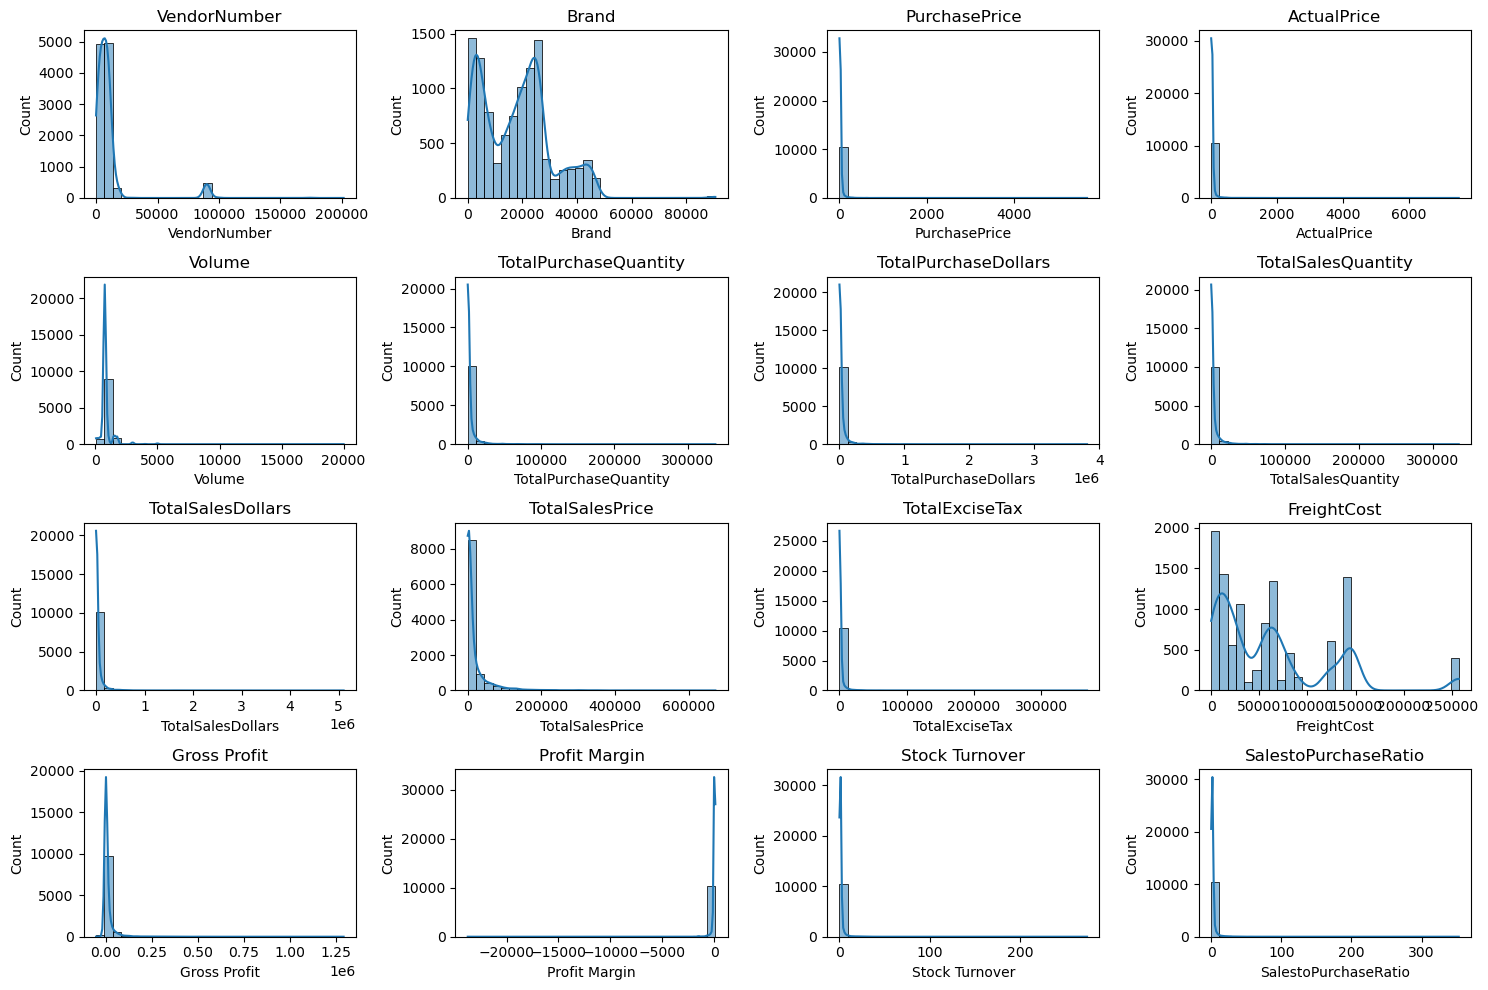

In [61]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)   # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

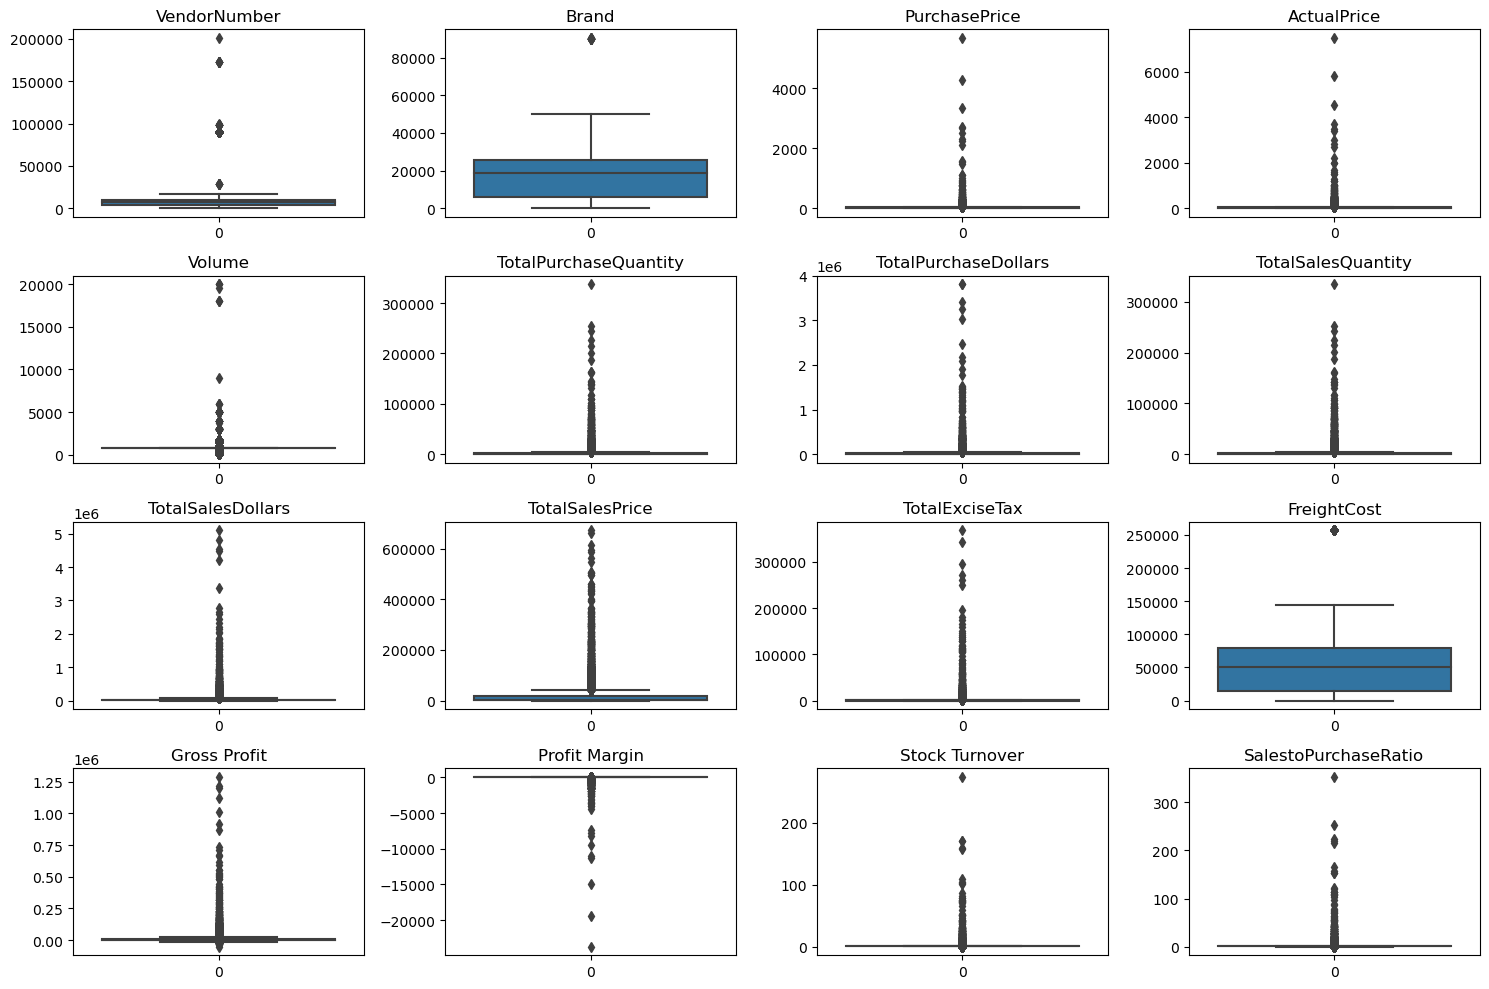

In [63]:
# Outlier Detection with Boxplots
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)   # Adjust grid layout as needed
    sns.boxplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# Summary Statistics Insights:
Negative & Zero Values:

Gross Profit: Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price..
Profit Margin: Has a minimum of -∞, which suggests cases where revenue is zero or even lower than costs.
Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.
Outliers Indicated by High Standard Deviations:

Purchase & Actual Prices: The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.
Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that Sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.

In [69]:
# let's filter the data by removing inconsistencies
df = pd.read_sql_query("""Select * from vendor_sales_summary Where "Gross Profit" > 0 AND "Profit Margin" > 0 AND TotalSalesQuantity > 0""",conn)

In [70]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,Gross Profit,Profit Margin,Stock Turnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8560,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8561,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8562,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.980000e+00,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8563,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,1.432800e+02,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


ValueError: num must be an integer with 1 <= num <= 16, not 17

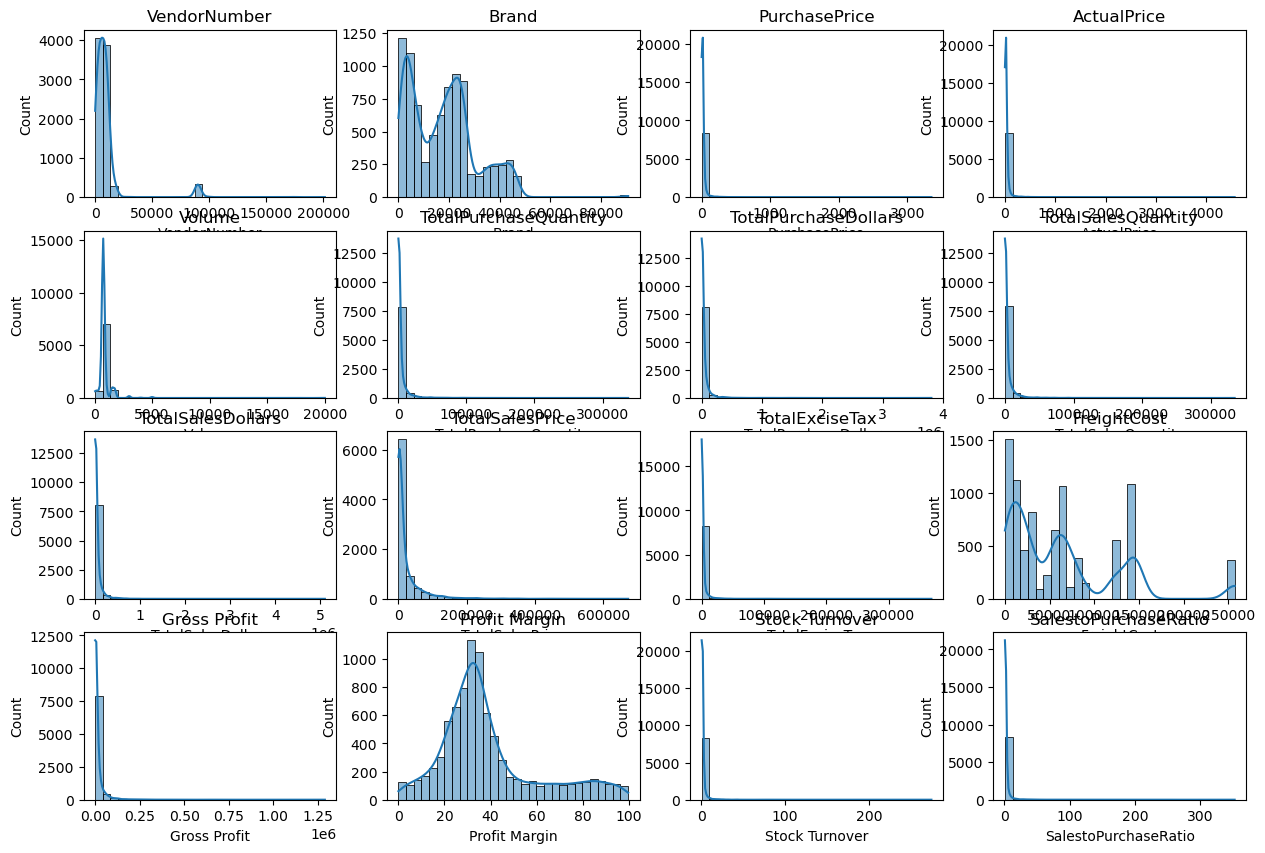

In [135]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)  # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

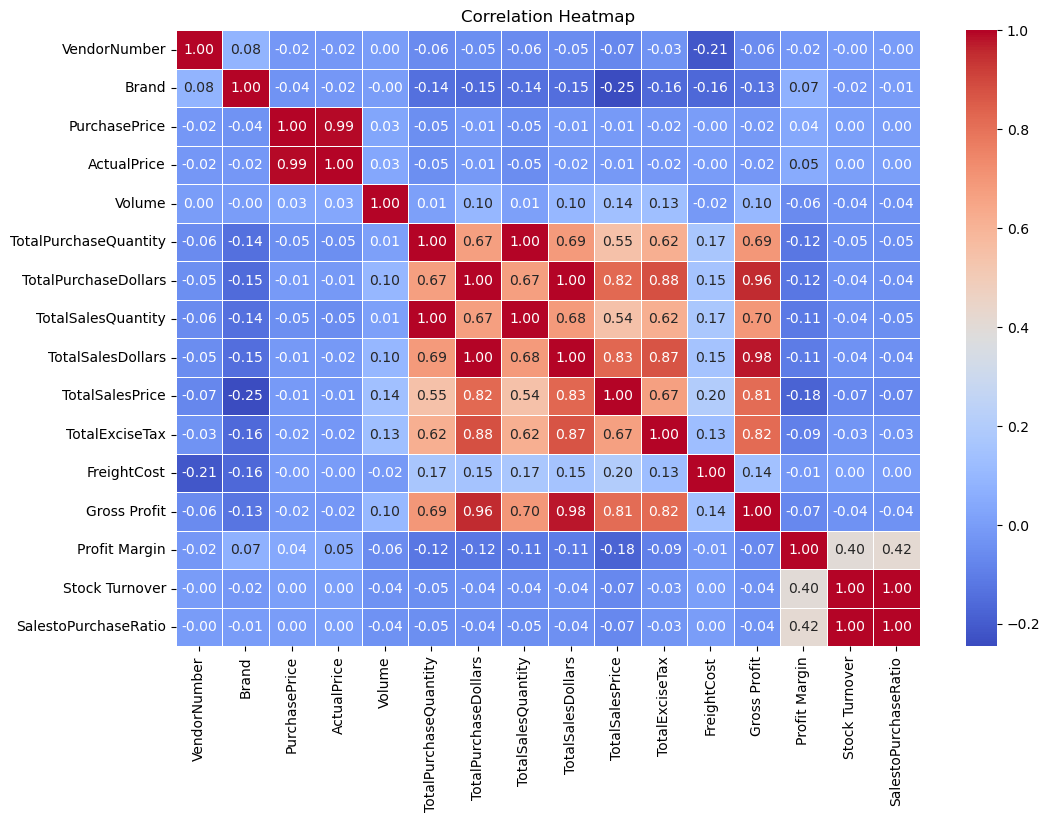

In [72]:
#correlation heatmap

plt.figure(figsize=(12, 8))

correlation_matrix = df[numerical_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

# Correlation Insights
PurchasePrice has weak correlations with TotalSalesDollars (-0.012) and GrossProfit (-0.016), suggesting that price variations do not significantly impact sales revenue or profit.
Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.
Negative correlation between profit margin & total sales price (-0.179) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.
StockTurnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.055), indicating that faster turnover does not necessarily result in higher profitability.

# DATA ANALYSIS

Identify Brands that needs Promotional or Pricing Adjustments which exhibit lower sales performance but higher profit margins.

In [137]:
brand_performance = df.groupby('Description').agg({'TotalSalesDollars':'sum','Profit Margin': 'mean'}).reset_index()
brand_performance.sort_values('Profit Margin')

,Description,TotalSalesDollars,Profit Margin
5485,Pepperjack Barossa Red,191.92,0.020842
2954,Flint & Steel Svgn Bl Napa V,119.92,0.033356
2179,Croft Tawny Porto,191.84,0.041701
2561,Douglass Hill Merlot,143.76,0.083472
5385,Parducci 13 True Grit Chard,24927.81,0.121190
...,...,...,...
4568,M Chiarlo Gavi Wh,1208.90,99.393664
657,Beniotome Sesame Shochu,4768.41,99.534226
6449,Skinnygirl Tangerine Vodka,2368.42,99.544844
2411,DiSaronno Amaretto,4781.16,99.553246


In [139]:
# threshold for "low sales" (bottom 15%) and "high margin" (top 15%)
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['Profit Margin'].quantile(0.85)

# Filter brands with low sales but high profit margins
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['Profit Margin'] >= high_margin_threshold)
]
print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,Profit Margin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [79]:
low_sales_threshold

560.299

In [80]:
high_margin_threshold

64.97017552750111

In [81]:
target_brands = brand_performance [(brand_performance['TotalSalesDollars'] <= low_sales_threshold) & (brand_performance['Profit Margin']
                                                                                                      >= high_margin_threshold)] 
print("Brands with low sales but high margins :")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with low sales but high margins :


,Description,TotalSalesDollars,Profit Margin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [90]:
brand_performance = brand_performance[
    brand_performance['TotalSalesDollars'] < 10000
]

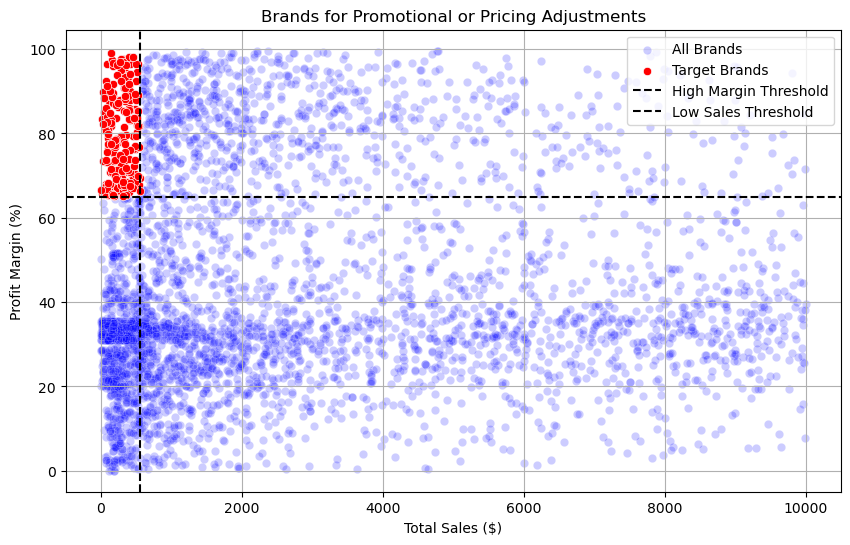

In [91]:
plt.figure(figsize=(10, 6))

# All brands
sns.scatterplot(
    data=brand_performance,
    x='TotalSalesDollars',
    y='Profit Margin',
    color='blue',
    label='All Brands',
    alpha=0.2
)

# Target brands
sns.scatterplot(
    data=target_brands,
    x='TotalSalesDollars',
    y='Profit Margin',
    color='red',
    label='Target Brands'
)

# Threshold lines
plt.axhline(high_margin_threshold, linestyle='--', color='black', label='High Margin Threshold')
plt.axvline(low_sales_threshold, linestyle='--', color='black', label='Low Sales Threshold')

# Labels & title
plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")

plt.legend()
plt.grid(True)
plt.show()

In [92]:
# Top Vendors & Brands by Sales Performance
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)

top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)

top_vendors

VendorName
DIAGEO NORTH AMERICA INC       6.799010e+07
MARTIGNETTI COMPANIES          3.927640e+07
PERNOD RICARD USA              3.206320e+07
JIM BEAM BRANDS COMPANY        3.142302e+07
BACARDI USA INC                2.485482e+07
CONSTELLATION BRANDS INC       2.421875e+07
E & J GALLO WINERY             1.839990e+07
BROWN-FORMAN CORP              1.824723e+07
ULTRA BEVERAGE COMPANY LLP     1.650254e+07
M S WALKER INC                 1.470646e+07
Name: TotalSalesDollars, dtype: float64

In [93]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

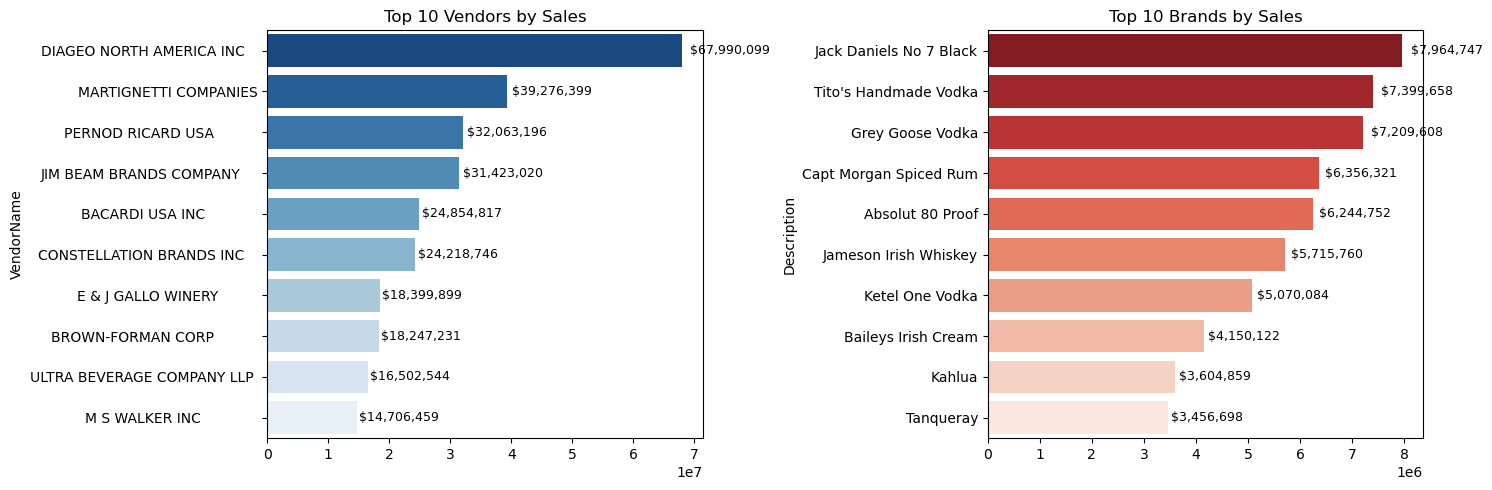

In [95]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(
    y=top_vendors.index,
    x=top_vendors.values,
    palette="Blues_r"
)
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    width = bar.get_width()
    ax1.text(
        width + width * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"${width:,.0f}",
        ha='left', va='center', fontsize=9
    )

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(
    y=top_brands.index,
    x=top_brands.values,
    palette="Reds_r"
)
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    width = bar.get_width()
    ax2.text(
        width + width * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"${width:,.0f}",
        ha='left', va='center', fontsize=9
    )

plt.tight_layout()
plt.show()

Which vendors contribute the most to total purchase dollars?


In [101]:
vendor_performance = df.groupby('VendorName').agg({'TotalPurchaseDollars' : 'sum', 'Gross Profit' : 'sum','TotalSalesDollars' : 'sum'}).reset_index()

In [102]:
vendor_performance['purchase contribution'] = vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()

In [106]:
vendor_performance.head(10)

,VendorName,TotalPurchaseDollars,Gross Profit,TotalSalesDollars,purchase contribution
0,ADAMBA IMPORTS INTL INC,446.16,2.583700e+02,7.045300e+02,0.000001
1,ALISA CARR BEVERAGES,25698.12,7.877282e+04,1.044709e+05,0.000084
2,ALTAMAR BRANDS LLC,11706.20,4.000610e+03,1.570681e+04,0.000038
3,AMERICAN SPIRITS EXCHANGE,934.08,5.770800e+02,1.511160e+03,0.000003
4,AMERICAN VINTAGE BEVERAGE,104435.68,3.516785e+04,1.396035e+05,0.000340
5,ATLANTIC IMPORTING COMPANY,41116.32,1.815643e+04,5.927275e+04,0.000134
6,BACARDI USA INC,17432020.26,7.422797e+06,2.485482e+07,0.056719
7,BANFI PRODUCTS CORP,1608143.72,1.023941e+06,2.632085e+06,0.005232
8,BLACK PRINCE DISTILLERY INC,5854.94,5.746260e+03,1.160120e+04,0.000019
9,BLACK ROCK SPIRITS LLC,1152.10,8.970800e+02,2.049180e+03,0.000004


In [140]:
# Rank Vendors by Total Purchase Dollars
vendor_performance = df.groupby("VendorName").agg({
    "TotalPurchaseDollars": "sum",
    "GrossProfit": "sum",
    "TotalSalesDollars":"sum"
}).reset_index()

# Calculate Contribution % to Overall Procurement
vendor_performance["Purchase_Contribution%"] = (vendor_performance["TotalPurchaseDollars"] / vendor_performance["TotalPurchaseDollars"].sum()) * 100

# Rank Vendors by Total Purchase Dollars & Profitability
vendor_performance = round(vendor_performance.sort_values(by="TotalPurchaseDollars", ascending=False),2)

# Display Top 10 Vendors
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['Gross Profit'] = top_vendors['Gross Profit'].apply(format_dollars)
top_vendors

KeyError: "Column(s) ['GrossProfit'] do not exist"

In [115]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)
    
# Rank Vendors by Total Purchase Dollars
vendor_performance = df.groupby("VendorName").agg({
    "TotalPurchaseDollars": "sum",
    "Gross Profit": "sum",
    "TotalSalesDollars":"sum"
}).reset_index()

# Calculate Contribution % to Overall Procurement
vendor_performance["Purchase_Contribution%"] = (vendor_performance["TotalPurchaseDollars"] / vendor_performance["TotalPurchaseDollars"].sum()) * 100

# Rank Vendors by Total Purchase Dollars & Profitability
vendor_performance = round(vendor_performance.sort_values(by="TotalPurchaseDollars", ascending=False),2)

# Display Top 10 Vendors
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['Gross Profit'] = top_vendors['Gross Profit'].apply(format_dollars)
top_vendors

C:\Users\Bodhiswatta Mukherje\AppData\Local\Temp\ipykernel_19132\1974663846.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
C:\Users\Bodhiswatta Mukherje\AppData\Local\Temp\ipykernel_19132\1974663846.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
C:\Users\Bodhiswatta Mukherje\AppData\Local\Temp\ipykernel_19132\197

,VendorName,TotalPurchaseDollars,Gross Profit,TotalSalesDollars,Purchase_Contribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30
57,MARTIGNETTI COMPANIES,25.46M,13.81M,39.28M,8.29
69,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93
107,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18


C:\Users\Bodhiswatta Mukherje\AppData\Local\Temp\ipykernel_19132\2916973626.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_vendors['Cumulative_Contribution%'] = top_vendors['Purchase_Contribution%'].cumsum()


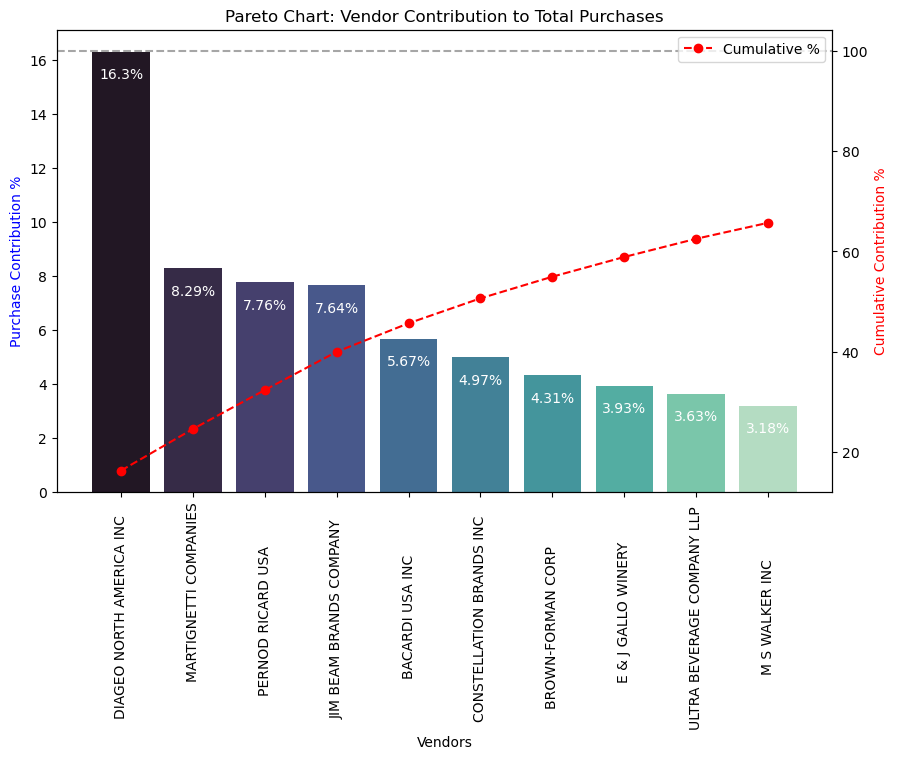

In [116]:
top_vendors['Cumulative_Contribution%'] = top_vendors['Purchase_Contribution%'].cumsum()

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['Purchase_Contribution%'],  palette="mako", ax=ax1)

for i, value in enumerate(top_vendors['Purchase_Contribution%']):
    ax1.text(i, value - 1, str(value)+'%', ha='center', fontsize=10, color='white')

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], color='red', marker='o', linestyle='dashed', label='Cumulative %')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.show()

C:\Users\Bodhiswatta Mukherje\AppData\Local\Temp\ipykernel_19132\2916973626.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_vendors['Cumulative_Contribution%'] = top_vendors['Purchase_Contribution%'].cumsum()


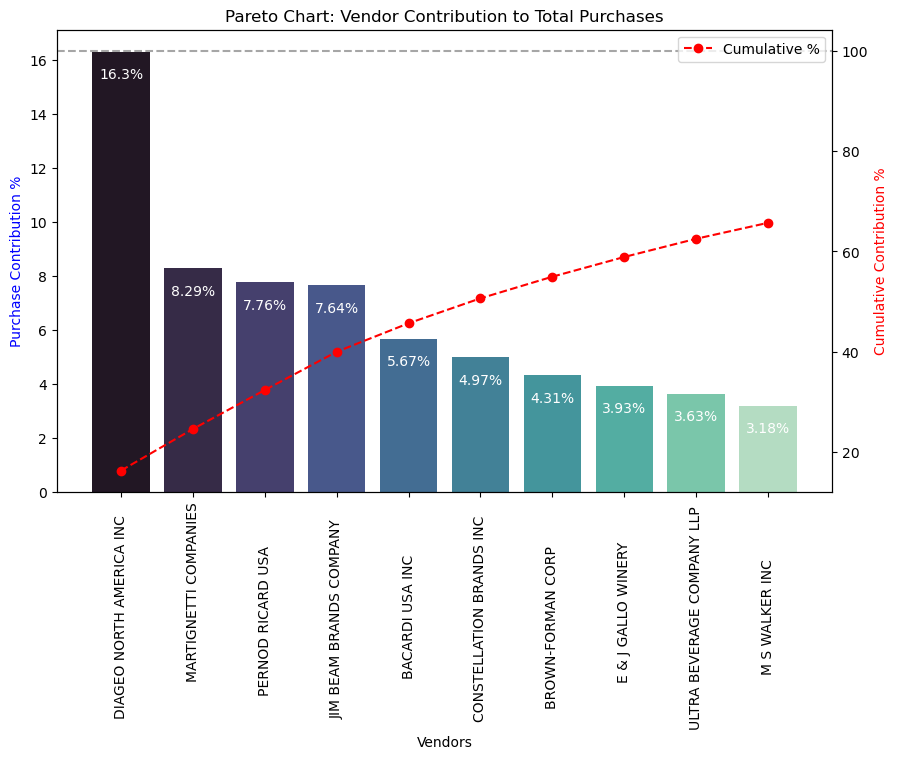

In [117]:
top_vendors['Cumulative_Contribution%'] = top_vendors['Purchase_Contribution%'].cumsum()

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['Purchase_Contribution%'],  palette="mako", ax=ax1)

for i, value in enumerate(top_vendors['Purchase_Contribution%']):
    ax1.text(i, value - 1, str(value)+'%', ha='center', fontsize=10, color='white')

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], color='red', marker='o', linestyle='dashed', label='Cumulative %')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.show()

How much procurement is dependent on bulk producers?


Total Purchase Contribution of top 10 vendors is 65.68 %


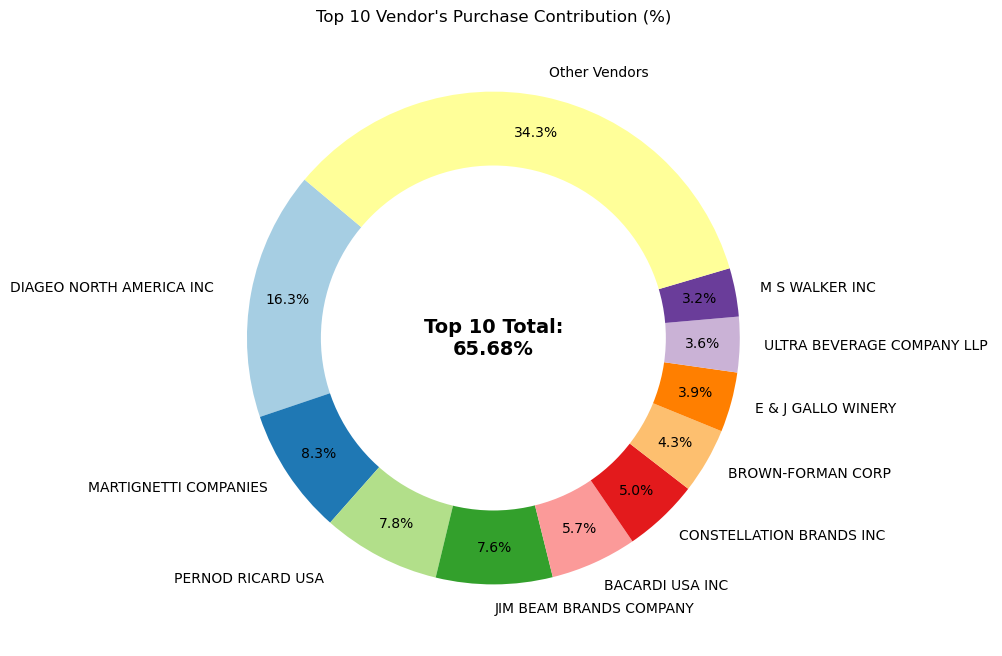

In [118]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['Purchase_Contribution%'].sum(),2)} %")

vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['Purchase_Contribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(purchase_contributions, labels=vendors, autopct='%1.1f%%',
                                  startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

Does purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost savings?

In [119]:
# Calculate Unit Purchase Price per Vendor & Volume Group
df["UnitPurchasePrice"] = df["TotalPurchaseDollars"] / df["TotalPurchaseQuantity"]

# Group by Order Sizes (e.g., Small, Medium, Large Purchases)
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])

# Analyze Cost Savings per Order Size
bulk_purchase_analysis = df.groupby("OrderSize")["UnitPurchasePrice"].mean().reset_index()
print(bulk_purchase_analysis)

  OrderSize  UnitPurchasePrice
0     Small          39.057543
1    Medium          15.486414
2     Large          10.777625


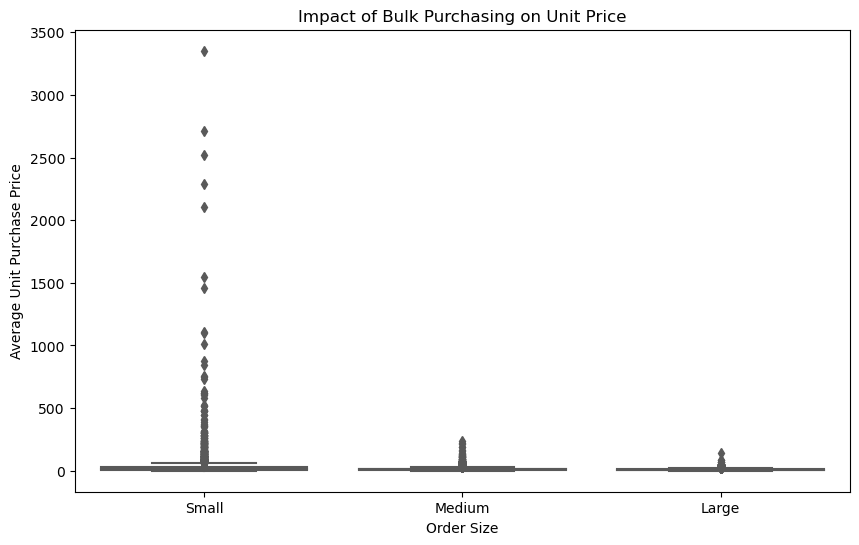

In [120]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.
The price difference between Small and Large orders is substantial (~72% reduction in unit cost)
This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit revenue.

Which vendors have low inventory turnover, indicating excess stock and slow-moving products?

In [122]:
# Identify Low Inventory Turnover Vendors
low_turnover_vendors = df[df["Stock Turnover"] < 1].groupby("VendorName")["Stock Turnover"].mean().reset_index()

# Sort by Lowest Turnover
low_turnover_vendors = low_turnover_vendors.sort_values(by="Stock Turnover", ascending=True)
low_turnover_vendors.head(10)

,VendorName,Stock Turnover
0,ALISA CARR BEVERAGES,0.615385
36,HIGHLAND WINE MERCHANTS LLC,0.708333
61,PARK STREET IMPORTS LLC,0.751306
19,Circa Wines,0.755676
26,Dunn Wine Brokers,0.766022
15,CENTEUR IMPORTS LLC,0.773953
79,SMOKY QUARTZ DISTILLERY LLC,0.783835
91,TAMWORTH DISTILLING,0.797078
92,THE IMPORTED GRAPE LLC,0.807569
102,WALPOLE MTN VIEW WINERY,0.820548


In [123]:
# Calculate Unsold Inventory Value
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print('Total Unsold Capital:', format_dollars(df["UnsoldInventoryValue"].sum()))

# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

Total Unsold Capital: 2.71M


,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
69,PERNOD RICARD USA,470.63K
117,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
80,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
62,MOET HENNESSY USA INC,126.48K
78,REMY COINTREAU USA INC,118.60K


NameError: name 'stats' is not defined

In [126]:
import scipy.stats as stats

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.17
Low Vendors 95% CI: (40.48, 42.62), Mean: 41.55


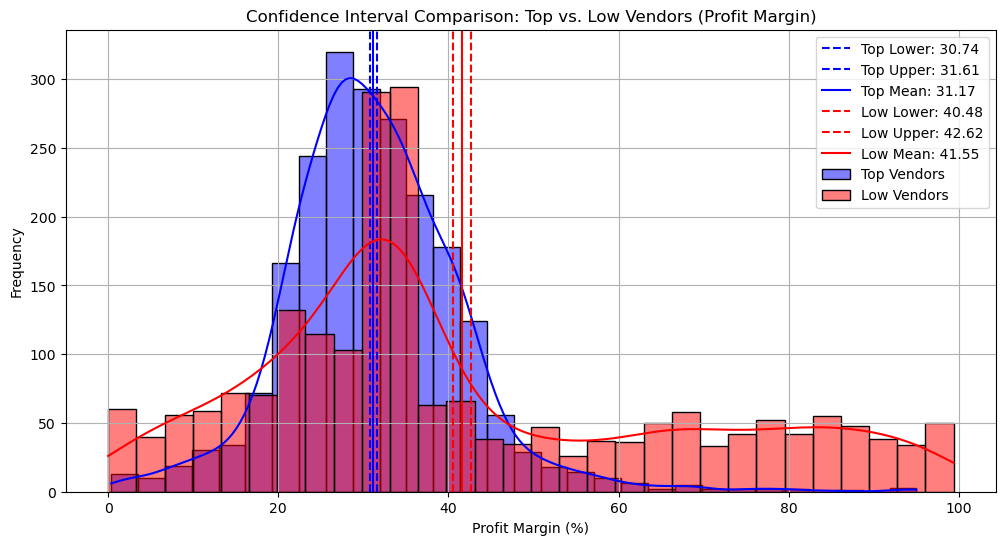

In [128]:
# Define top and low vendors based on Total Sales Dollars (Top 25% & Bottom 25%)
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["Profit Margin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["Profit Margin"].dropna()

# Function to compute confidence interval
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

# Compute confidence intervals
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

In [129]:
vendor_performance.to_csv("vendor_performance.csv", index=False)

In [130]:
vendor_sales_summary.to_csv("vendor_sales_summary.csv", index=False)

In [131]:
top_vendors.to_csv("top_vendors.csv", index=False)

In [132]:
brand_performance.to_csv("brand_performance.csv", index=False)